In [36]:
%pip install -q "torch>=2.3,<3" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4"

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import math
import os
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import wandb

SEED = 42
WANDB_ENTITY = "kende23-n-a"
WANDB_PROJECT = "Walmart-Recruiting---Store-Sales-Forecasting"
WANDB_GROUP = "nbeats-experiments"

DATA_DIR_CANDIDATES = [
    Path('/content/drive/MyDrive/walmart_competition_data'),
    Path('/content/drive/My Drive/walmart_competition_data'),
    Path('/content/walmart_competition_data'),
    Path('../../data'),
    Path('data'),
]

OUTPUT_DIR = Path('/content/artifacts/nbeats_baseline') if Path('/content').exists() else Path('artifacts/nbeats_baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'validation_weeks': 32,
    'context_length': 52,
    'forecast_horizon': 32,
    'min_series_length': 84,
    'batch_size': 128,
    'max_epochs': 100,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'hidden_units': 256,
    'num_blocks': 4,
    'num_layers': 4,
    'dropout': 0.10,
    'holiday_weight': 5.0,
    'clip_grad_norm': 1.0,
    'num_workers': 2,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)
print(f"Using device: {CONFIG['device']}")
print(f"Python: {platform.python_version()}")
print(f"Torch: {torch.__version__}")

Using device: cuda
Python: 3.12.13
Torch: 2.11.0+cu128


In [39]:
def resolve_data_dir(candidates):
    for candidate in candidates:
        if candidate.exists() and (candidate / 'train.csv').exists():
            return candidate
    searched = '\n'.join(str(path) for path in candidates)
    raise FileNotFoundError(f'Could not find train.csv. Searched:\n{searched}')


DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)
print(f'Data directory: {DATA_DIR}')

train_raw = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['Date'])
test_raw = pd.read_csv(DATA_DIR / 'test.csv', parse_dates=['Date'])
features_raw = pd.read_csv(DATA_DIR / 'features.csv', parse_dates=['Date'])
stores_raw = pd.read_csv(DATA_DIR / 'stores.csv')

required_train_cols = {'Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'}
missing_cols = required_train_cols.difference(train_raw.columns)
if missing_cols:
    raise ValueError(f'train.csv is missing required columns: {sorted(missing_cols)}')

print('train shape:', train_raw.shape)
print('test shape:', test_raw.shape)
print('features shape:', features_raw.shape)
print('stores shape:', stores_raw.shape)
print('date range:', train_raw['Date'].min().date(), 'to', train_raw['Date'].max().date())

Data directory: /content/drive/MyDrive/walmart_competition_data
train shape: (421570, 5)
test shape: (115064, 4)
features shape: (8190, 12)
stores shape: (45, 3)
date range: 2010-02-05 to 2012-10-26


In [40]:
train_df = train_raw.copy()
train_df['Store'] = train_df['Store'].astype(int)
train_df['Dept'] = train_df['Dept'].astype(int)
train_df = train_df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

all_dates = pd.date_range(train_df['Date'].min(), train_df['Date'].max(), freq='W-FRI')
sales_pivot = (
    train_df
    .pivot_table(index=['Store', 'Dept'], columns='Date', values='Weekly_Sales', aggfunc='sum')
    .reindex(columns=all_dates)
    .sort_index()
)

holiday_by_date = (
    train_df.groupby('Date')['IsHoliday']
    .max()
    .reindex(all_dates)
    .fillna(False)
    .astype(bool)
)

context_length = CONFIG['context_length']
forecast_horizon = CONFIG['forecast_horizon']
validation_weeks = CONFIG['validation_weeks']
min_required_weeks = context_length + forecast_horizon

valid_series_mask = sales_pivot.notna().sum(axis=1) >= min_required_weeks
sales_pivot = sales_pivot.loc[valid_series_mask]
filled_sales = sales_pivot.ffill(axis=1).bfill(axis=1).fillna(0.0)

series_index = filled_sales.index
series_keys = pd.DataFrame(series_index.tolist(), columns=['Store', 'Dept'])

if validation_weeks != forecast_horizon:
    raise ValueError('This baseline expects validation_weeks to equal forecast_horizon.')

validation_start = len(all_dates) - validation_weeks
if validation_start < context_length:
    raise ValueError('Not enough historical weeks before validation. Reduce context_length or validation_weeks.')

train_dates = all_dates[:validation_start]
validation_dates = all_dates[validation_start:]

sales_values_original = filled_sales.to_numpy(dtype=np.float32)
log_sales_values = np.log1p(np.clip(sales_values_original, a_min=0.0, a_max=None)).astype(np.float32)

series_center = log_sales_values[:, :validation_start].mean(axis=1, keepdims=True)
series_scale = log_sales_values[:, :validation_start].std(axis=1, keepdims=True)
series_scale = np.where(series_scale < 1e-6, 1.0, series_scale).astype(np.float32)
normalized_values = ((log_sales_values - series_center) / series_scale).astype(np.float32)

print('weekly dates:', len(all_dates))
print('usable Store-Dept series:', len(series_index))
print('training date range:', train_dates.min().date(), 'to', train_dates.max().date())
print('validation date range:', validation_dates.min().date(), 'to', validation_dates.max().date())
print('sales tensor shape:', normalized_values.shape)

weekly dates: 143
usable Store-Dept series: 2921
training date range: 2010-02-05 to 2012-03-16
validation date range: 2012-03-23 to 2012-10-26
sales tensor shape: (2921, 143)


In [41]:
def make_training_windows(
    values: np.ndarray,
    horizon_weights: np.ndarray,
    context: int,
    horizon: int,
    validation_start_idx: int,
):
    X_windows = []
    y_windows = []
    weight_windows = []
    last_window_start = validation_start_idx - context - horizon
    if last_window_start < 0:
        raise ValueError('Not enough history to create training windows before validation.')

    for series_id in range(values.shape[0]):
        for start in range(last_window_start + 1):
            split = start + context
            target_slice = slice(split, split + horizon)
            X_windows.append(values[series_id, start:split])
            y_windows.append(values[series_id, target_slice])
            weight_windows.append(horizon_weights[target_slice])

    return (
        np.asarray(X_windows, dtype=np.float32),
        np.asarray(y_windows, dtype=np.float32),
        np.asarray(weight_windows, dtype=np.float32),
    )


all_horizon_weights = np.where(
    holiday_by_date.to_numpy(dtype=bool),
    CONFIG['holiday_weight'],
    1.0,
).astype(np.float32)

X_train, y_train, train_target_weights = make_training_windows(
    normalized_values,
    all_horizon_weights,
    context_length,
    forecast_horizon,
    validation_start,
)

X_val = normalized_values[:, validation_start - context_length:validation_start].astype(np.float32)
y_val_original = sales_values_original[:, validation_start:validation_start + forecast_horizon].astype(np.float32)
val_holiday_flags = holiday_by_date.loc[validation_dates].to_numpy(dtype=bool)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('train_target_weights:', train_target_weights.shape)
print('X_val:', X_val.shape)
print('y_val:', y_val_original.shape)
print('validation holiday weeks:', int(val_holiday_flags.sum()))

X_train: (81788, 52)
y_train: (81788, 32)
train_target_weights: (81788, 32)
X_val: (2921, 52)
y_val: (2921, 32)
validation holiday weeks: 1


## 4. Log preprocessing to W&B

The W&B preprocessing run records this as Experiment 3 and logs that holiday-aware target weights were added for the training loss.


In [42]:
wandb.login(key=os.environ.get('WANDB_API_KEY'), relogin=False)

preprocessing_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type='experiment_preprocessing',
    name='NBEATS_Experiment_03_Holiday_Weighted_Loss_Preprocessing',
    config={
        **CONFIG,
        'seed': SEED,
        'model_family': 'N-BEATS',
        'experiment_type': 'experiment_03_holiday_weighted_loss',
        'data_dir': str(DATA_DIR),
        'train_rows': int(len(train_raw)),
        'test_rows': int(len(test_raw)),
        'usable_series': int(len(series_index)),
        'train_windows': int(len(X_train)),
        'total_weeks': int(len(all_dates)),
        'train_start_date': str(train_dates.min().date()),
        'train_end_date': str(train_dates.max().date()),
        'validation_start_date': str(validation_dates.min().date()),
        'validation_end_date': str(validation_dates.max().date()),
        'target_transform': 'clip_negative_then_log1p',
        'series_scaling': 'per_series_standardization_fit_on_training_period',
        'feature_engineering': 'holiday_aware_target_weights',
        'baseline_reference_weighted_mae': 2157.9829,
        'experiment_1_reference_weighted_mae': 2186.5015,
        'experiment_2_reference_weighted_mae': 2662.8061,
        'training_change': 'weighted_l1_loss_by_target_holiday_weeks',
    },
)

preprocessing_table = wandb.Table(
    columns=['step', 'purpose'],
    data=[
        ['sort_by_time', 'Required so windows use past-to-future order.'],
        ['pivot_series', 'Required to convert rows into Store-Dept time-series tensors.'],
        ['fill_missing_tensor_values', 'Required because neural network tensors cannot contain NaN.'],
        ['time_validation_split', 'Required to avoid future leakage.'],
        ['log_and_scale_target', 'Required for stable neural-network optimization.'],
        ['sliding_windows', 'Required to create supervised N-BEATS training samples.'],
    ],
)
preprocessing_run.log({
    'experiment_03_preprocessing/steps': preprocessing_table,
    'experiment_03_preprocessing/usable_series': len(series_index),
    'experiment_03_preprocessing/train_windows': len(X_train),
})
preprocessing_run.finish()

experiment_03_preprocessing/train_windows,▁
experiment_03_preprocessing/usable_series,▁
experiment_03_preprocessing/train_windows,81788
experiment_03_preprocessing/usable_series,2921


In [43]:
class WindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray | None = None, weights: np.ndarray | None = None):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = None if y is None else torch.from_numpy(y.astype(np.float32))
        self.weights = None if weights is None else torch.from_numpy(weights.astype(np.float32))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        if self.weights is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.weights[idx]


class NBeatsBlock(nn.Module):
    def __init__(self, input_size: int, horizon: int, hidden_units: int, num_layers: int, dropout: float):
        super().__init__()
        layers = []
        current_size = input_size
        for _ in range(num_layers):
            layers.append(nn.Linear(current_size, hidden_units))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            current_size = hidden_units
        self.net = nn.Sequential(*layers)
        self.backcast_head = nn.Linear(hidden_units, input_size)
        self.forecast_head = nn.Linear(hidden_units, horizon)

    def forward(self, x):
        hidden = self.net(x)
        return self.backcast_head(hidden), self.forecast_head(hidden)


class NBeats(nn.Module):
    def __init__(self, input_size: int, horizon: int, hidden_units: int, num_blocks: int, num_layers: int, dropout: float):
        super().__init__()
        self.horizon = horizon
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, horizon, hidden_units, num_layers, dropout)
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        residual = x
        forecast = torch.zeros(x.size(0), self.horizon, device=x.device)
        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast
            forecast = forecast + block_forecast
        return forecast


def inverse_transform_predictions(pred_normalized: np.ndarray, center: np.ndarray, scale: np.ndarray) -> np.ndarray:
    pred_log = pred_normalized * scale + center
    pred_sales = np.expm1(pred_log)
    return np.clip(pred_sales, a_min=0.0, a_max=None)


def weighted_mae(y_true: np.ndarray, y_pred: np.ndarray, holiday_flags: np.ndarray, holiday_weight: float = 5.0) -> float:
    weights = np.where(holiday_flags.reshape(1, -1), holiday_weight, 1.0)
    weights = np.broadcast_to(weights, y_true.shape)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

## 6. Seasonal naive reference

In [45]:
seasonal_naive_pred = sales_values_original[:, validation_start - forecast_horizon:validation_start]
baseline_wmae = weighted_mae(y_val_original, seasonal_naive_pred, val_holiday_flags, CONFIG['holiday_weight'])
baseline_mae = mae(y_val_original, seasonal_naive_pred)
baseline_rmse = rmse(y_val_original, seasonal_naive_pred)

print(f'Seasonal naive validation WMAE: {baseline_wmae:.4f}')
print(f'Seasonal naive validation MAE: {baseline_mae:.4f}')
print(f'Seasonal naive validation RMSE: {baseline_rmse:.4f}')

Seasonal naive validation WMAE: 3902.8521
Seasonal naive validation MAE: 3946.3479
Seasonal naive validation RMSE: 10482.2129


In [46]:
def evaluate_model(model: nn.Module, X: np.ndarray, batch_size: int = 512):
    model.eval()
    predictions = []
    loader = DataLoader(WindowDataset(X), batch_size=batch_size, shuffle=False, num_workers=0)
    with torch.no_grad():
        for batch_X in loader:
            batch_X = batch_X.to(CONFIG['device'])
            predictions.append(model(batch_X).cpu().numpy())
    return np.concatenate(predictions, axis=0)


def weighted_l1_loss(prediction: torch.Tensor, target: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    return (torch.abs(prediction - target) * weights).sum() / weights.sum()


train_loader = DataLoader(
    WindowDataset(X_train, y_train, train_target_weights),
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['device'] == 'cuda',
)

model = NBeats(
    input_size=context_length,
    horizon=forecast_horizon,
    hidden_units=CONFIG['hidden_units'],
    num_blocks=CONFIG['num_blocks'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout'],
).to(CONFIG['device'])

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

training_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type='experiment_training',
    name='NBEATS_Experiment_03_Holiday_Weighted_Loss',
    config={
        **CONFIG,
        'seed': SEED,
        'model_family': 'N-BEATS',
        'experiment_type': 'experiment_03_holiday_weighted_loss',
        'feature_engineering': 'holiday_aware_target_weights',
        'search_strategy': 'single_fixed_run',
        'baseline_seasonal_naive_weighted_mae': baseline_wmae,
        'baseline_reference_weighted_mae': 2157.9829,
        'experiment_1_reference_weighted_mae': 2186.5015,
        'experiment_2_reference_weighted_mae': 2662.8061,
        'training_change': 'weighted_l1_loss_by_target_holiday_weeks',
        'train_windows': int(len(X_train)),
        'validation_series': int(len(X_val)),
    },
)
wandb.watch(model, log='gradients', log_freq=100)

best_validation_wmae = math.inf
best_epoch = -1
best_val_pred_original = None
history = []

for epoch in range(1, CONFIG['max_epochs'] + 1):
    model.train()
    train_losses = []

    for batch_X, batch_y, batch_weights in train_loader:
        batch_X = batch_X.to(CONFIG['device'])
        batch_y = batch_y.to(CONFIG['device'])
        batch_weights = batch_weights.to(CONFIG['device'])

        optimizer.zero_grad(set_to_none=True)
        batch_pred = model(batch_X)
        loss = weighted_l1_loss(batch_pred, batch_y, batch_weights)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad_norm'])
        optimizer.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_pred_normalized = evaluate_model(model, X_val)
    val_pred_original = inverse_transform_predictions(val_pred_normalized, series_center, series_scale)

    validation_wmae = weighted_mae(y_val_original, val_pred_original, val_holiday_flags, CONFIG['holiday_weight'])
    validation_mae = mae(y_val_original, val_pred_original)
    validation_rmse = rmse(y_val_original, val_pred_original)
    scheduler.step(validation_wmae)

    metrics = {
        'epoch': epoch,
        'train/weighted_l1_log_scaled': train_loss,
        'validation/weighted_mae': validation_wmae,
        'validation/mae': validation_mae,
        'validation/rmse': validation_rmse,
        'learning_rate': optimizer.param_groups[0]['lr'],
    }
    training_run.log(metrics)
    history.append(metrics)

    if validation_wmae < best_validation_wmae:
        best_validation_wmae = validation_wmae
        best_epoch = epoch
        best_val_pred_original = val_pred_original.copy()

    print(
        f"Epoch {epoch:03d}/{CONFIG['max_epochs']:03d} | "
        f"train weighted L1={train_loss:.5f} | val WMAE={validation_wmae:.4f} | val MAE={validation_mae:.4f}"
    )

training_run.summary['best_epoch'] = best_epoch
training_run.summary['best_validation_weighted_mae'] = best_validation_wmae
training_run.summary['baseline_seasonal_naive_weighted_mae'] = baseline_wmae
training_run.summary['baseline_reference_weighted_mae'] = 2157.9829
training_run.summary['experiment_1_reference_weighted_mae'] = 2186.5015
training_run.summary['experiment_2_reference_weighted_mae'] = 2662.8061
training_run.summary['training_change'] = 'weighted_l1_loss_by_target_holiday_weeks'
training_run.finish()

print(f'Best epoch: {best_epoch}')
print(f'Best validation weighted MAE: {best_validation_wmae:.4f}')

Epoch 001/100 | train weighted L1=0.54881 | val WMAE=2216.2192 | val MAE=2189.5129
Epoch 002/100 | train weighted L1=0.50778 | val WMAE=2220.4615 | val MAE=2180.7957
Epoch 003/100 | train weighted L1=0.49422 | val WMAE=2250.8430 | val MAE=2219.3794
Epoch 004/100 | train weighted L1=0.48553 | val WMAE=2230.4517 | val MAE=2198.7268
Epoch 005/100 | train weighted L1=0.47892 | val WMAE=2185.1366 | val MAE=2160.8167
Epoch 006/100 | train weighted L1=0.47354 | val WMAE=2242.0777 | val MAE=2209.4902
Epoch 007/100 | train weighted L1=0.46909 | val WMAE=2246.7419 | val MAE=2212.6812
Epoch 008/100 | train weighted L1=0.46561 | val WMAE=2256.8055 | val MAE=2222.3298
Epoch 009/100 | train weighted L1=0.46241 | val WMAE=2259.4078 | val MAE=2227.4517
Epoch 010/100 | train weighted L1=0.44945 | val WMAE=2230.4306 | val MAE=2197.3611
Epoch 011/100 | train weighted L1=0.44429 | val WMAE=2243.1462 | val MAE=2208.9814
Epoch 012/100 | train weighted L1=0.44188 | val WMAE=2229.0930 | val MAE=2199.3291
Epoc

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇██
learning_rate,████▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/weighted_l1_log_scaled,█▆▅▅▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation/mae,▂▁▄▆█▆▄▆▄▄▆▅▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆
validation/rmse,▁▄█▇▃▅▇▄▂▅▅▅▅▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅
validation/weighted_mae,▄▄▇▁█▅▇▆▇▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆
baseline_reference_weighted_mae,2157.9829
baseline_seasonal_naive_weighted_mae,3902.85206
best_epoch,5
best_validation_weighted_mae,2185.13665
epoch,100


Best epoch: 5
Best validation weighted MAE: 2185.1366


## 8. Validation diagnostics and W&B logging

This logs evaluation outputs for Experiment 3. It still does not log trained model weights and does not register a model.


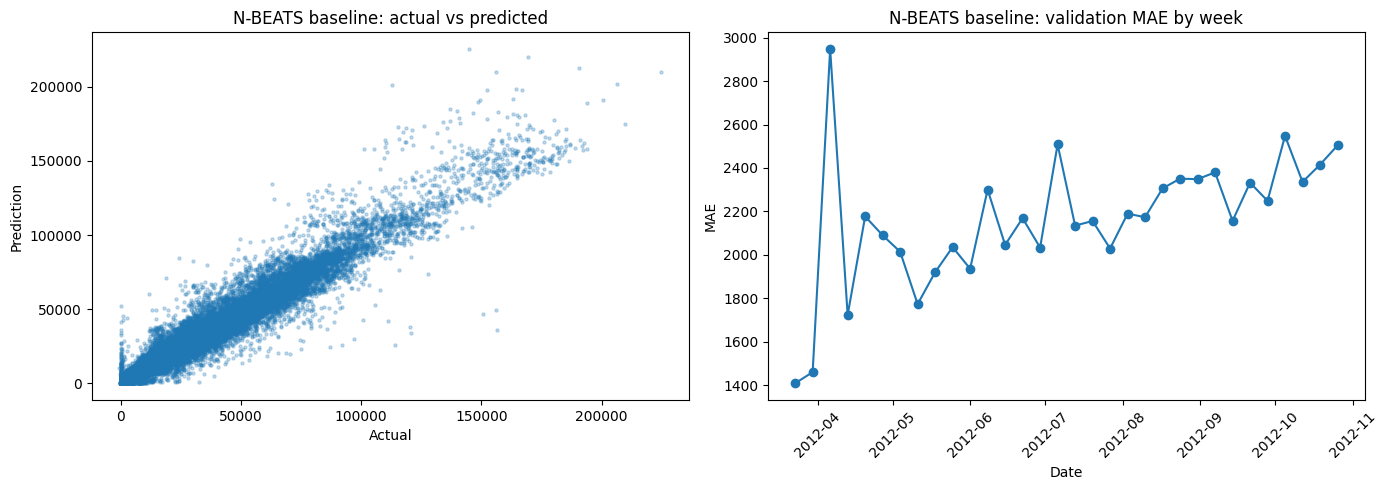

experiment_03/best_validation_weighted_mae,▁
experiment_03/seasonal_naive_weighted_mae,▁
experiment_03/best_validation_weighted_mae,2185.13665
experiment_03/seasonal_naive_weighted_mae,3902.85206


Logged Experiment 3 metrics, diagnostics, and evaluation artifact to W&B.
No model artifact or Model Registry entry was created.


In [47]:
prediction_rows = []
for series_id, (store, dept) in enumerate(series_index):
    for horizon_idx, date in enumerate(validation_dates):
        actual = float(y_val_original[series_id, horizon_idx])
        prediction = float(best_val_pred_original[series_id, horizon_idx])
        prediction_rows.append({
            'Store': int(store),
            'Dept': int(dept),
            'Date': date,
            'Weekly_Sales': actual,
            'Prediction': prediction,
            'IsHoliday': bool(val_holiday_flags[horizon_idx]),
            'AbsoluteError': abs(actual - prediction),
        })

val_predictions_df = pd.DataFrame(prediction_rows)
weekly_errors_df = (
    val_predictions_df
    .groupby('Date', as_index=False)
    .agg(Weekly_MAE=('AbsoluteError', 'mean'), IsHoliday=('IsHoliday', 'max'))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(val_predictions_df['Weekly_Sales'], val_predictions_df['Prediction'], s=5, alpha=0.25)
axes[0].set_title('N-BEATS baseline: actual vs predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Prediction')

axes[1].plot(weekly_errors_df['Date'], weekly_errors_df['Weekly_MAE'], marker='o')
axes[1].set_title('N-BEATS baseline: validation MAE by week')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

predictions_path = OUTPUT_DIR / 'experiment_03_validation_predictions.csv'
weekly_errors_path = OUTPUT_DIR / 'experiment_03_weekly_validation_errors.csv'
history_path = OUTPUT_DIR / 'experiment_03_training_history.csv'

val_predictions_df.to_csv(predictions_path, index=False)
weekly_errors_df.to_csv(weekly_errors_path, index=False)
pd.DataFrame(history).to_csv(history_path, index=False)

evaluation_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type='experiment_evaluation',
    name='NBEATS_Experiment_03_Evaluation_No_Model_Artifact',
    config={
        **CONFIG,
        'seed': SEED,
        'model_family': 'N-BEATS',
        'experiment_type': 'experiment_03_holiday_weighted_loss',
        'feature_engineering': 'holiday_aware_target_weights',
        'best_epoch': best_epoch,
        'best_validation_weighted_mae': best_validation_wmae,
        'baseline_seasonal_naive_weighted_mae': baseline_wmae,
        'baseline_reference_weighted_mae': 2157.9829,
        'experiment_1_reference_weighted_mae': 2186.5015,
        'experiment_2_reference_weighted_mae': 2662.8061,
        'training_change': 'weighted_l1_loss_by_target_holiday_weeks',
    },
)

evaluation_artifact = wandb.Artifact(
    name='nbeats-experiment-03-evaluation',
    type='evaluation',
    description='N-BEATS Experiment 3 validation predictions and diagnostics. No model weights included.',
    metadata={
        'feature_engineering': 'holiday_aware_target_weights',
        'best_epoch': int(best_epoch),
        'best_validation_weighted_mae': float(best_validation_wmae),
    },
)
evaluation_artifact.add_file(str(predictions_path), name='experiment_03_validation_predictions.csv')
evaluation_artifact.add_file(str(weekly_errors_path), name='experiment_03_weekly_validation_errors.csv')
evaluation_artifact.add_file(str(history_path), name='experiment_03_training_history.csv')

evaluation_run.log({
    'experiment_03/diagnostic_plots': wandb.Image(fig),
    'experiment_03/predictions_sample': wandb.Table(dataframe=val_predictions_df.head(1000)),
    'experiment_03/weekly_errors': wandb.Table(dataframe=weekly_errors_df),
    'experiment_03/best_validation_weighted_mae': best_validation_wmae,
    'experiment_03/seasonal_naive_weighted_mae': baseline_wmae,
})
evaluation_run.log_artifact(evaluation_artifact)
evaluation_run.finish()

print('Logged Experiment 3 metrics, diagnostics, and evaluation artifact to W&B.')
print('No model artifact or Model Registry entry was created.')

## 9. After running this experiment

Compare `best_validation_weighted_mae` against the previous results:

```text
Baseline N-BEATS best WMAE = 2157.9829 at epoch 2
Experiment 1 best WMAE = 2186.5015 at epoch 7
Experiment 2 best WMAE = 2662.8061 at epoch 2
```

Send the new best WMAE, best epoch, and training log. Then `n-beats.md` can be updated with whether holiday-aware weighted loss improved the model or not.
